In [1]:
# import packages for data processing
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer

# import packages for data visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# import packages for statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency

# import packages for model building


# set display options
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/raw/train.csv')


# Feature Engineering for Text Classification

This notebook creates comprehensive features from the text data for our binary classification task.

## Dataset Overview
- **Task**: Binary classification (label 0 vs 1)
- **Features**: Text column containing academic/technical writing samples
- **Size**: 4,712 samples
- **Class Distribution**: Imbalanced (0: 3,233, 1: 1,479)

In [3]:
# Basic exploration
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nClass balance: {df['label'].value_counts(normalize=True)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nText length statistics:\n{df['text'].str.len().describe()}")

Dataset shape: (4712, 2)

Label distribution:
label
0    3233
1    1479
Name: count, dtype: int64

Class balance: label
0    0.686121
1    0.313879
Name: proportion, dtype: float64

Missing values:
text     0
label    0
dtype: int64

Text length statistics:
count    4712.000000
mean      820.294779
std       321.889996
min       105.000000
25%       620.000000
50%       760.000000
75%       944.000000
max      7500.000000
Name: text, dtype: float64


## 1. Text Statistical Features

We'll extract various statistical features from the text including:
- Basic counts (characters, words, sentences)
- Average metrics (word length, sentence length)
- Punctuation and special character counts
- Capitalization patterns

In [4]:
import re
import string
from collections import Counter

def extract_text_statistics(text):
    """Extract comprehensive statistical features from text"""
    features = {}
    
    # Basic length features
    features['char_count'] = len(text)
    features['word_count'] = len(text.split())
    
    # Sentence count (split by . ! ?)
    sentences = re.split(r'[.!?]+', text)
    features['sentence_count'] = len([s for s in sentences if s.strip()])
    
    # Average metrics
    words = text.split()
    features['avg_word_length'] = np.mean([len(w) for w in words]) if words else 0
    features['avg_sentence_length'] = features['word_count'] / features['sentence_count'] if features['sentence_count'] > 0 else 0
    
    # Punctuation counts
    features['comma_count'] = text.count(',')
    features['semicolon_count'] = text.count(';')
    features['colon_count'] = text.count(':')
    features['period_count'] = text.count('.')
    features['exclamation_count'] = text.count('!')
    features['question_count'] = text.count('?')
    features['quote_count'] = text.count('"') + text.count("'")
    features['parenthesis_count'] = text.count('(') + text.count(')')
    features['dash_count'] = text.count('-') + text.count('–') + text.count('—')
    
    # Total punctuation
    punctuation_chars = string.punctuation
    features['total_punctuation'] = sum(text.count(p) for p in punctuation_chars)
    features['punctuation_ratio'] = features['total_punctuation'] / features['char_count'] if features['char_count'] > 0 else 0
    
    # Capitalization features
    features['uppercase_count'] = sum(1 for c in text if c.isupper())
    features['uppercase_ratio'] = features['uppercase_count'] / features['char_count'] if features['char_count'] > 0 else 0
    features['title_word_count'] = sum(1 for w in words if w.istitle())
    
    # Digit features
    features['digit_count'] = sum(1 for c in text if c.isdigit())
    features['digit_ratio'] = features['digit_count'] / features['char_count'] if features['char_count'] > 0 else 0
    
    # Whitespace features
    features['space_count'] = text.count(' ')
    features['newline_count'] = text.count('\n')
    
    # Special characters
    features['special_char_count'] = sum(1 for c in text if not c.isalnum() and not c.isspace())
    
    return features

# Apply feature extraction
print("Extracting text statistical features...")
stat_features = df['text'].apply(extract_text_statistics).apply(pd.Series)
print(f"Created {len(stat_features.columns)} statistical features")
stat_features.head()

Extracting text statistical features...
Created 24 statistical features
Created 24 statistical features


,char_count,word_count,sentence_count,avg_word_length,avg_sentence_length,comma_count,semicolon_count,colon_count,period_count,exclamation_count,question_count,quote_count,parenthesis_count,dash_count,total_punctuation,punctuation_ratio,uppercase_count,uppercase_ratio,title_word_count,digit_count,digit_ratio,space_count,newline_count,special_char_count
0,855.0,146.0,7.0,4.863014,20.857143,4.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,11.0,0.012865,10.0,0.011696,7.0,2.0,0.002339,145.0,0.0,22.0
1,880.0,139.0,5.0,5.338129,27.800000,5.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,10.0,0.011364,10.0,0.011364,10.0,1.0,0.001136,138.0,0.0,16.0
2,777.0,111.0,5.0,6.009009,22.200000,12.0,2.0,0.0,5.0,0.0,0.0,3.0,0.0,1.0,25.0,0.032175,9.0,0.011583,5.0,0.0,0.000000,110.0,0.0,25.0
3,546.0,89.0,4.0,5.146067,22.250000,3.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,1.0,8.0,0.014652,5.0,0.009158,4.0,4.0,0.007326,88.0,0.0,8.0
4,883.0,145.0,4.0,5.096552,36.250000,2.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,3.0,10.0,0.011325,31.0,0.035108,17.0,0.0,0.000000,144.0,0.0,14.0


## 2. Linguistic Features

Advanced linguistic features including:
- Vocabulary richness (unique words, lexical diversity)
- Part-of-speech distribution
- Readability scores (Flesch, Gunning Fog)
- Syntactic complexity

In [13]:
# Install required packages if needed
import subprocess
import sys

try:
    import nltk
    import textstat
except ImportError:
    print("Installing required packages...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk", "textstat"])
    import nltk
    import textstat

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')
    
try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')
    
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag

print("Required libraries loaded successfully!")

Required libraries loaded successfully!


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/maximus/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [14]:
def extract_linguistic_features(text):
    """Extract advanced linguistic features"""
    features = {}
    
    # Tokenization
    words = word_tokenize(text.lower())
    sentences = sent_tokenize(text)
    
    # Vocabulary richness
    unique_words = set(words)
    features['unique_word_count'] = len(unique_words)
    features['lexical_diversity'] = len(unique_words) / len(words) if words else 0
    
    # Stopword analysis
    stop_words = set(stopwords.words('english'))
    features['stopword_count'] = sum(1 for w in words if w in stop_words)
    features['stopword_ratio'] = features['stopword_count'] / len(words) if words else 0
    
    # Word length distribution
    word_lengths = [len(w) for w in words if w.isalpha()]
    if word_lengths:
        features['min_word_length'] = min(word_lengths)
        features['max_word_length'] = max(word_lengths)
        features['std_word_length'] = np.std(word_lengths)
    else:
        features['min_word_length'] = 0
        features['max_word_length'] = 0
        features['std_word_length'] = 0
    
    # Long/short word counts
    features['short_word_count'] = sum(1 for w in words if len(w) <= 3)
    features['long_word_count'] = sum(1 for w in words if len(w) >= 10)
    
    # Readability scores
    features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
    features['flesch_kincaid_grade'] = textstat.flesch_kincaid_grade(text)
    features['gunning_fog'] = textstat.gunning_fog(text)
    features['smog_index'] = textstat.smog_index(text)
    features['automated_readability_index'] = textstat.automated_readability_index(text)
    features['coleman_liau_index'] = textstat.coleman_liau_index(text)
    features['syllable_count'] = textstat.syllable_count(text)
    features['polysyllable_count'] = textstat.polysyllabcount(text)
    
    # POS tagging (sample first 100 words for efficiency)
    sample_words = words[:100] if len(words) > 100 else words
    pos_tags = pos_tag(sample_words)
    pos_counts = Counter(tag for word, tag in pos_tags)
    
    # Common POS tag ratios
    total_pos = len(pos_tags)
    features['noun_ratio'] = (pos_counts.get('NN', 0) + pos_counts.get('NNS', 0) + 
                              pos_counts.get('NNP', 0) + pos_counts.get('NNPS', 0)) / total_pos if total_pos > 0 else 0
    features['verb_ratio'] = (pos_counts.get('VB', 0) + pos_counts.get('VBD', 0) + 
                             pos_counts.get('VBG', 0) + pos_counts.get('VBN', 0) + 
                             pos_counts.get('VBP', 0) + pos_counts.get('VBZ', 0)) / total_pos if total_pos > 0 else 0
    features['adj_ratio'] = (pos_counts.get('JJ', 0) + pos_counts.get('JJR', 0) + 
                            pos_counts.get('JJS', 0)) / total_pos if total_pos > 0 else 0
    features['adv_ratio'] = (pos_counts.get('RB', 0) + pos_counts.get('RBR', 0) + 
                            pos_counts.get('RBS', 0)) / total_pos if total_pos > 0 else 0
    
    return features

# Apply linguistic feature extraction (this may take a few minutes)
print("Extracting linguistic features (this may take 2-3 minutes)...")
linguistic_features = df['text'].apply(extract_linguistic_features).apply(pd.Series)
print(f"Created {len(linguistic_features.columns)} linguistic features")
linguistic_features.head()

Extracting linguistic features (this may take 2-3 minutes)...
Created 21 linguistic features
Created 21 linguistic features


,unique_word_count,lexical_diversity,stopword_count,stopword_ratio,min_word_length,max_word_length,std_word_length,short_word_count,long_word_count,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,smog_index,automated_readability_index,coleman_liau_index,syllable_count,polysyllable_count,noun_ratio,verb_ratio,adj_ratio,adv_ratio
0,77.0,0.452941,66.0,0.388235,1.0,11.0,2.672462,90.0,8.0,50.652671,11.375793,13.548337,13.256717,11.903366,10.112329,233.0,22.0,0.330000,0.100000,0.100000,0.040000
1,93.0,0.600000,59.0,0.380645,1.0,14.0,2.774265,64.0,12.0,37.415122,14.946964,17.738705,15.381576,17.612590,13.428777,232.0,23.0,0.300000,0.150000,0.090000,0.020000
2,91.0,0.664234,42.0,0.306569,1.0,13.0,3.036555,58.0,16.0,26.534432,15.073405,20.411532,17.805411,17.972432,16.412613,207.0,33.0,0.300000,0.170000,0.080000,0.030000
3,62.0,0.652632,40.0,0.421053,2.0,15.0,2.889552,41.0,8.0,42.617542,12.842556,15.192135,13.816670,13.932978,12.195506,149.0,14.0,0.305263,0.147368,0.073684,0.021053
4,101.0,0.660131,60.0,0.392157,1.0,12.0,2.625456,57.0,12.0,30.056250,17.824167,19.773759,16.526678,20.199759,13.182979,235.0,22.0,0.320000,0.140000,0.200000,0.010000


## 3. Sentiment and Emotion Features

Extract sentiment polarity and subjectivity scores using TextBlob.

In [8]:
try:
    from textblob import TextBlob
except ImportError:
    print("Installing textblob...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "textblob"])
    from textblob import TextBlob

def extract_sentiment_features(text):
    """Extract sentiment and subjectivity scores"""
    features = {}
    
    # Create TextBlob object
    blob = TextBlob(text)
    
    # Overall sentiment
    features['sentiment_polarity'] = blob.sentiment.polarity
    features['sentiment_subjectivity'] = blob.sentiment.subjectivity
    
    # Sentence-level sentiment statistics
    sentence_polarities = [s.sentiment.polarity for s in blob.sentences]
    if sentence_polarities:
        features['sentiment_polarity_mean'] = np.mean(sentence_polarities)
        features['sentiment_polarity_std'] = np.std(sentence_polarities)
        features['sentiment_polarity_min'] = np.min(sentence_polarities)
        features['sentiment_polarity_max'] = np.max(sentence_polarities)
        
        # Count positive, negative, neutral sentences
        features['positive_sentence_count'] = sum(1 for p in sentence_polarities if p > 0.1)
        features['negative_sentence_count'] = sum(1 for p in sentence_polarities if p < -0.1)
        features['neutral_sentence_count'] = sum(1 for p in sentence_polarities if -0.1 <= p <= 0.1)
    else:
        features['sentiment_polarity_mean'] = 0
        features['sentiment_polarity_std'] = 0
        features['sentiment_polarity_min'] = 0
        features['sentiment_polarity_max'] = 0
        features['positive_sentence_count'] = 0
        features['negative_sentence_count'] = 0
        features['neutral_sentence_count'] = 0
    
    return features

# Apply sentiment feature extraction
print("Extracting sentiment features...")
sentiment_features = df['text'].apply(extract_sentiment_features).apply(pd.Series)
print(f"Created {len(sentiment_features.columns)} sentiment features")
sentiment_features.head()

Installing textblob...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 15.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Extracting sentiment features...
Created 9 sentiment features


,sentiment_polarity,sentiment_subjectivity,sentiment_polarity_mean,sentiment_polarity_std,sentiment_polarity_min,sentiment_polarity_max,positive_sentence_count,negative_sentence_count,neutral_sentence_count
0,0.186833,0.568037,0.151373,0.139447,0.000000,0.450000,5.0,0.0,2.0
1,0.094420,0.474107,0.108937,0.051782,0.030000,0.166667,2.0,0.0,3.0
2,0.073077,0.453846,0.038000,0.129950,-0.166667,0.190000,2.0,1.0,2.0
3,0.066667,0.766667,0.066667,0.094281,0.000000,0.200000,1.0,0.0,2.0
4,0.046684,0.439031,-0.016994,0.111951,-0.190476,0.122500,1.0,1.0,2.0


## 4. N-gram Features

Extract common phrases and patterns using bigrams and trigrams.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

def extract_ngram_features(text):
    """Extract n-gram based features"""
    features = {}
    
    words = text.lower().split()
    
    # Bigrams
    bigrams = [' '.join(words[i:i+2]) for i in range(len(words)-1)]
    features['bigram_count'] = len(bigrams)
    features['unique_bigram_count'] = len(set(bigrams))
    features['bigram_diversity'] = features['unique_bigram_count'] / features['bigram_count'] if features['bigram_count'] > 0 else 0
    
    # Trigrams
    trigrams = [' '.join(words[i:i+3]) for i in range(len(words)-2)]
    features['trigram_count'] = len(trigrams)
    features['unique_trigram_count'] = len(set(trigrams))
    features['trigram_diversity'] = features['unique_trigram_count'] / features['trigram_count'] if features['trigram_count'] > 0 else 0
    
    # Repeated n-grams (indicator of repetitive content)
    bigram_counts = Counter(bigrams)
    trigram_counts = Counter(trigrams)
    features['max_bigram_frequency'] = max(bigram_counts.values()) if bigram_counts else 0
    features['max_trigram_frequency'] = max(trigram_counts.values()) if trigram_counts else 0
    
    return features

# Apply n-gram feature extraction
print("Extracting n-gram features...")
ngram_features = df['text'].apply(extract_ngram_features).apply(pd.Series)
print(f"Created {len(ngram_features.columns)} n-gram features")
ngram_features.head()

Extracting n-gram features...
Created 8 n-gram features


,bigram_count,unique_bigram_count,bigram_diversity,trigram_count,unique_trigram_count,trigram_diversity,max_bigram_frequency,max_trigram_frequency
0,145.0,112.0,0.772414,144.0,127.0,0.881944,4.0,2.0
1,138.0,133.0,0.963768,137.0,137.0,1.000000,2.0,1.0
2,110.0,106.0,0.963636,109.0,108.0,0.990826,3.0,2.0
3,88.0,86.0,0.977273,87.0,87.0,1.000000,2.0,1.0
4,144.0,138.0,0.958333,143.0,142.0,0.993007,2.0,2.0


## 5. Domain-Specific Features

Extract features specific to academic/technical writing.

In [10]:
def extract_domain_features(text):
    """Extract domain-specific features for academic/technical text"""
    features = {}
    
    text_lower = text.lower()
    
    # Technical/academic keywords
    technical_terms = ['model', 'data', 'dataset', 'analysis', 'feature', 'performance', 
                      'prediction', 'classification', 'regression', 'accuracy', 'result',
                      'machine learning', 'algorithm', 'training', 'testing', 'validation']
    features['technical_term_count'] = sum(text_lower.count(term) for term in technical_terms)
    
    # Statistical terms
    statistical_terms = ['mean', 'median', 'standard deviation', 'correlation', 'probability',
                        'distribution', 'statistical', 'significance', 'hypothesis', 'variance']
    features['statistical_term_count'] = sum(text_lower.count(term) for term in statistical_terms)
    
    # Research methodology terms
    method_terms = ['methodology', 'approach', 'technique', 'method', 'procedure', 'process',
                   'experiment', 'study', 'research', 'investigation']
    features['methodology_term_count'] = sum(text_lower.count(term) for term in method_terms)
    
    # Evaluation terms
    eval_terms = ['evaluate', 'evaluation', 'metric', 'measure', 'assess', 'compare',
                 'comparison', 'performance', 'effectiveness', 'efficiency']
    features['evaluation_term_count'] = sum(text_lower.count(term) for term in eval_terms)
    
    # Numbers and percentages
    features['number_count'] = len(re.findall(r'\d+', text))
    features['percentage_count'] = len(re.findall(r'\d+%', text))
    features['decimal_count'] = len(re.findall(r'\d+\.\d+', text))
    
    # Citations and references (approximate)
    features['citation_count'] = len(re.findall(r'\(\d{4}\)', text))  # Year in parentheses
    features['et_al_count'] = text_lower.count('et al')
    
    # Figure/Table references
    features['figure_mention_count'] = len(re.findall(r'figure\s+\d+', text_lower))
    features['table_mention_count'] = len(re.findall(r'table\s+\d+', text_lower))
    features['appendix_mention_count'] = len(re.findall(r'appendix\s+[a-z]', text_lower))
    
    # First-person vs third-person
    first_person = ['we', 'our', 'us', 'i', 'my', 'me']
    features['first_person_count'] = sum(len(re.findall(r'\b' + term + r'\b', text_lower)) for term in first_person)
    
    # Formal conjunctions
    formal_conj = ['however', 'therefore', 'furthermore', 'moreover', 'nevertheless', 'consequently']
    features['formal_conjunction_count'] = sum(len(re.findall(r'\b' + term + r'\b', text_lower)) for term in formal_conj)
    
    # Hedging words (uncertainty)
    hedging = ['may', 'might', 'could', 'possibly', 'perhaps', 'approximately', 'likely', 'suggest']
    features['hedging_word_count'] = sum(len(re.findall(r'\b' + term + r'\b', text_lower)) for term in hedging)
    
    return features

# Apply domain feature extraction
print("Extracting domain-specific features...")
domain_features = df['text'].apply(extract_domain_features).apply(pd.Series)
print(f"Created {len(domain_features.columns)} domain-specific features")
domain_features.head()

Extracting domain-specific features...
Created 15 domain-specific features


,technical_term_count,statistical_term_count,methodology_term_count,evaluation_term_count,number_count,percentage_count,decimal_count,citation_count,et_al_count,figure_mention_count,table_mention_count,appendix_mention_count,first_person_count,formal_conjunction_count,hedging_word_count
0,12,1,0,0,2,0,0,0,0,0,0,0,0,0,0
1,3,2,1,0,1,0,0,0,0,0,0,0,2,0,0
2,2,0,1,0,0,0,0,0,0,0,0,0,0,0,1
3,3,0,0,3,4,0,1,0,0,0,0,0,3,0,0
4,14,0,1,4,0,0,0,0,0,0,0,0,1,0,0


## 6. Combine All Features

Now let's combine all engineered features into a single dataframe.

In [15]:
# Combine all feature sets
df_features = pd.concat([
    df[['text', 'label']],
    stat_features,
    linguistic_features,
    sentiment_features,
    ngram_features,
    domain_features
], axis=1)

print(f"Combined dataset shape: {df_features.shape}")
print(f"Total features created: {df_features.shape[1] - 2}")  # Subtract text and label columns
print(f"\nFeature categories:")
print(f"  - Statistical: {len(stat_features.columns)}")
print(f"  - Linguistic: {len(linguistic_features.columns)}")
print(f"  - Sentiment: {len(sentiment_features.columns)}")
print(f"  - N-gram: {len(ngram_features.columns)}")
print(f"  - Domain-specific: {len(domain_features.columns)}")

df_features.head()

Combined dataset shape: (4712, 79)
Total features created: 77

Feature categories:
  - Statistical: 24
  - Linguistic: 21
  - Sentiment: 9
  - N-gram: 8
  - Domain-specific: 15


,text,label,char_count,word_count,sentence_count,avg_word_length,avg_sentence_length,comma_count,semicolon_count,colon_count,period_count,exclamation_count,question_count,quote_count,parenthesis_count,dash_count,total_punctuation,punctuation_ratio,uppercase_count,uppercase_ratio,title_word_count,digit_count,digit_ratio,space_count,newline_count,special_char_count,unique_word_count,lexical_diversity,stopword_count,stopword_ratio,min_word_length,max_word_length,std_word_length,short_word_count,long_word_count,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,smog_index,automated_readability_index,coleman_liau_index,syllable_count,polysyllable_count,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sentiment_polarity,sentiment_subjectivity,sentiment_polarity_mean,sentiment_polarity_std,sentiment_polarity_min,sentiment_polarity_max,positive_sentence_count,negative_sentence_count,neutral_sentence_count,bigram_count,unique_bigram_count,bigram_diversity,trigram_count,unique_trigram_count,trigram_diversity,max_bigram_frequency,max_trigram_frequency,technical_term_count,statistical_term_count,methodology_term_count,evaluation_term_count,number_count,percentage_count,decimal_count,citation_count,et_al_count,figure_mention_count,table_mention_count,appendix_mention_count,first_person_count,formal_conjunction_count,hedging_word_count
0,"The width of the block represents the importance of the feature for the specific row. The wider the block is, the more important the feature is to push the predicted probability. The model predicted the case 1 user correctly as a depressed user. Their mention of “划破” and low percentage of positive words mentioned largely affect the model to predict it as a depressed user. The model predicted the case 2 user correctly as a normal user. The fact that they didn’t mention “共青团员” and “划破” and the high value of percentage of positive words mentioned push the model to predict it as a normal user. To sum up the feature importance section, different from the assumption and the word frequency analysis in the exploratory data analysis part, frequents words mentioned by depressed users such as “痛苦”,“抑郁” are not the important features in the XGBoost model.",0,855.0,146.0,7.0,4.863014,20.857143,4.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,11.0,0.012865,10.0,0.011696,7.0,2.0,0.002339,145.0,0.0,22.0,77.0,0.452941,66.0,0.388235,1.0,11.0,2.672462,90.0,8.0,50.652671,11.375793,13.548337,13.256717,11.903366,10.112329,233.0,22.0,0.330000,0.100000,0.100000,0.040000,0.186833,0.568037,0.151373,0.139447,0.000000,0.450000,5.0,0.0,2.0,145.0,112.0,0.772414,144.0,127.0,0.881944,4.0,2.0,12,1,0,0,2,0,0,0,0,0,0,0,0,0,0
1,"Quality of constructed questions are typically improved over time with more experience in question asking. Our model targets to help users who are less familiar with the posting questions or facing difficulties in framing the questions in the right manner, to improve their question posts. While absolute scores provide an indication of the question quality, it will be difficult for less experienced users to interpret the meaning of the score considering the infinite score range. As such, unlike the existing studies on Stack Overflow that predict scores as a regression problem, our project will be approaching the business problem as a classification problem and advise users on whether their draft posts are considered “Good”, “Normal” or “Bad”. Having 3 categories is meant to provide users a relative sense of how much improvement is needed for their draft question posts.",0,880.0,139.0,5.0,5.338129,27.800000,5.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,10.0,0.011364,10.0,0.011364,10.0,1.0,0.001136,138.0,0.0,16.0,93.0,0.600000,59.0,0.380645,1.0,14.0,2.774265,64.0,12.0,37.415122,14.946964,17.738705,15.381576,17.612590,13.428777,232.0,23.0,0.300000,0.150000,0.090000,0.020000,0.094420,0.474107,0.108937,0.051782,0.030000,0.166667,2.0,0.0,3.0,138.0,133.0,0.963768,137.0,137.0,1.000000,2.0,1.0,3,2,1,0,1,0,0,0,0,0,0,0,2,0,0
2,"The sentiment score of a loa

In [16]:
# Check for missing values and data types
print("Missing values per feature:")
print(df_features.isnull().sum()[df_features.isnull().sum() > 0])

print("\nFeature data types:")
print(df_features.dtypes.value_counts())

Missing values per feature:
Series([], dtype: int64)

Feature data types:
float64    62
int64      16
object      1
Name: count, dtype: int64


## 7. Feature Analysis and Visualization

Let's analyze the engineered features and see how they differ between classes.

In [17]:
# Get numeric feature columns (exclude text and label)
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
if 'label' in numeric_cols:
    numeric_cols.remove('label')

# Compare feature means by class
feature_comparison = df_features.groupby('label')[numeric_cols].mean().T
feature_comparison['difference'] = abs(feature_comparison[0] - feature_comparison[1])
feature_comparison = feature_comparison.sort_values('difference', ascending=False)

print("Top 20 features with largest mean difference between classes:")
print(feature_comparison.head(20))

Top 20 features with largest mean difference between classes:
label                          0           1  difference
char_count            828.906898  801.469236   27.437662
space_count           129.967522  113.942529   16.024994
trigram_count         128.960408  113.011494   15.948914
bigram_count          129.960408  114.011494   15.948914
word_count            130.960408  115.011494   15.948914
flesch_reading_ease    38.464638   22.988231   15.476408
short_word_count       65.234148   50.087897   15.146251
unique_trigram_count  126.668729  112.555105   14.113624
stopword_count         53.028147   42.040568   10.987579
unique_bigram_count   122.216208  111.425287   10.790921
polysyllable_count     24.788122   30.721433    5.933311
uppercase_count        18.697804   13.409060    5.288744
digit_count             7.574698    3.019608    4.555091
long_word_count        12.119394   15.873563    3.754169
special_char_count     21.546861   17.955375    3.591485
coleman_liau_index     12.

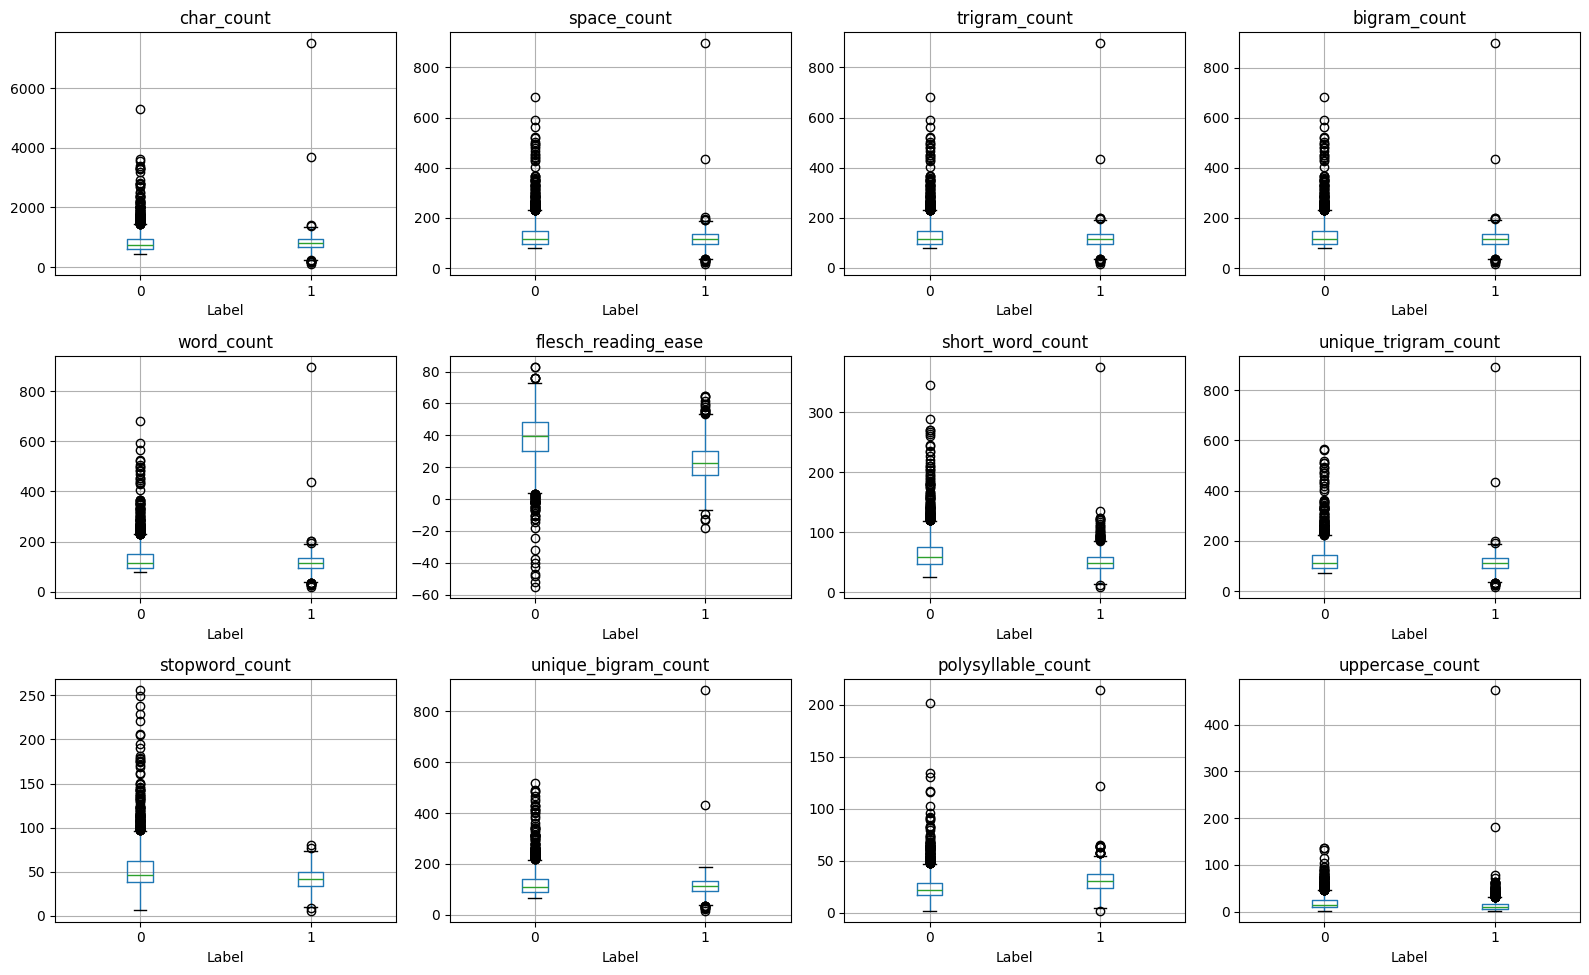

In [18]:
# Visualize top discriminative features
top_features = feature_comparison.head(12).index

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    df_features.boxplot(column=feature, by='label', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Label')
    plt.suptitle('')
    
plt.tight_layout()
plt.show()

In [21]:
# Correlation analysis
correlation_matrix = df_features[numeric_cols].corr()

# Find highly correlated feature pairs (above 0.9)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > 0.9):")
    for feat1, feat2, corr in high_corr_pairs[:10]:
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("No highly correlated feature pairs found (|r| > 0.9)")

Found 55 highly correlated feature pairs (|r| > 0.9):
  char_count <-> word_count: 0.974
  char_count <-> space_count: 0.974
  char_count <-> unique_word_count: 0.944
  char_count <-> syllable_count: 0.992
  char_count <-> bigram_count: 0.974
  char_count <-> unique_bigram_count: 0.974
  char_count <-> trigram_count: 0.974
  char_count <-> unique_trigram_count: 0.974
  word_count <-> space_count: 1.000
  word_count <-> unique_word_count: 0.916


## 8. TF-IDF Features

Create TF-IDF vectors from the text data for additional representation.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF features (limiting to top 500 features for efficiency)
tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english'
)

tfidf_features = tfidf_vectorizer.fit_transform(df['text'])
tfidf_df = pd.DataFrame(
    tfidf_features.toarray(),
    columns=[f'tfidf_{i}' for i in range(tfidf_features.shape[1])]
)

print(f"Created {tfidf_df.shape[1]} TF-IDF features")
print(f"TF-IDF matrix shape: {tfidf_features.shape}")

# Show top terms by TF-IDF score for each class
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop 20 TF-IDF terms for class 0:")
class0_avg = tfidf_features[df['label'] == 0].mean(axis=0).A1
top_indices_0 = class0_avg.argsort()[-20:][::-1]
for idx in top_indices_0:
    print(f"  {feature_names[idx]}: {class0_avg[idx]:.4f}")

print("\nTop 20 TF-IDF terms for class 1:")
class1_avg = tfidf_features[df['label'] == 1].mean(axis=0).A1
top_indices_1 = class1_avg.argsort()[-20:][::-1]
for idx in top_indices_1:
    print(f"  {feature_names[idx]}: {class1_avg[idx]:.4f}")

Created 500 TF-IDF features
TF-IDF matrix shape: (4712, 500)

Top 20 TF-IDF terms for class 0:


AttributeError: 'Series' object has no attribute 'nonzero'

## 9. Save Processed Features

Save all engineered features to the processed data folder for modeling.

In [28]:
import os

# Create processed data directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save engineered features (without text column to save space)
df_features_final = pd.concat([df_features.drop('text', axis=1), tfidf_df], axis=1)
df_features_final.to_csv('../data/processed/train_features.csv', index=False)

print(f"Saved engineered features to ../data/processed/train_features.csv")
print(f"Final dataset shape: {df_features_final.shape}")
print(f"Total features: {df_features_final.shape[1] - 1}")  # Subtract label column

# Save feature names for reference
feature_names_list = [col for col in df_features_final.columns if col != 'label']
with open('../data/processed/feature_names.txt', 'w') as f:
    for feature in feature_names_list:
        f.write(f"{feature}\n")

print(f"Saved feature names to ../data/processed/feature_names.txt")

Saved engineered features to ../data/processed/train_features.csv
Final dataset shape: (4712, 578)
Total features: 577
Saved feature names to ../data/processed/feature_names.txt


In [25]:
# Also save the TF-IDF vectorizer for later use on test data
import pickle

with open('../data/processed/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print("Saved TF-IDF vectorizer to ../data/processed/tfidf_vectorizer.pkl")

Saved TF-IDF vectorizer to ../data/processed/tfidf_vectorizer.pkl


## 10. Feature Summary

Summary of all engineered features and their categories.

In [26]:
print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(f"\nOriginal dataset: {df.shape}")
print(f"Final dataset: {df_features_final.shape}")
print(f"\nFeature Categories:")
print(f"  1. Statistical Features: {len(stat_features.columns)}")
print(f"     - Basic counts, lengths, punctuation, capitalization")
print(f"\n  2. Linguistic Features: {len(linguistic_features.columns)}")
print(f"     - Vocabulary richness, readability scores, POS tags")
print(f"\n  3. Sentiment Features: {len(sentiment_features.columns)}")
print(f"     - Polarity, subjectivity, sentence-level sentiment")
print(f"\n  4. N-gram Features: {len(ngram_features.columns)}")
print(f"     - Bigram and trigram patterns")
print(f"\n  5. Domain-Specific Features: {len(domain_features.columns)}")
print(f"     - Academic/technical terms, citations, formal language")
print(f"\n  6. TF-IDF Features: {tfidf_df.shape[1]}")
print(f"     - Top 500 unigrams and bigrams")
print(f"\nTotal Engineered Features: {df_features_final.shape[1] - 1}")
print(f"\nOutput files:")
print(f"  - ../data/processed/train_features.csv")
print(f"  - ../data/processed/feature_names.txt")
print(f"  - ../data/processed/tfidf_vectorizer.pkl")
print("="*80)

FEATURE ENGINEERING SUMMARY

Original dataset: (4712, 2)
Final dataset: (4712, 579)

Feature Categories:
  1. Statistical Features: 24
     - Basic counts, lengths, punctuation, capitalization

  2. Linguistic Features: 21
     - Vocabulary richness, readability scores, POS tags

  3. Sentiment Features: 9
     - Polarity, subjectivity, sentence-level sentiment

  4. N-gram Features: 8
     - Bigram and trigram patterns

  5. Domain-Specific Features: 15
     - Academic/technical terms, citations, formal language

  6. TF-IDF Features: 500
     - Top 500 unigrams and bigrams

Total Engineered Features: 578

Output files:
  - ../data/processed/train_features.csv
  - ../data/processed/feature_names.txt
  - ../data/processed/tfidf_vectorizer.pkl
